<a href="https://colab.research.google.com/github/Sudarshanks1212/-Air-Quality-Index.ipynb/blob/main/studentPerformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STUDENT PERFORMANCE**

Student academic performance is influenced by several factors such as study hours, attendance, parental support, extracurricular activities, and previous academic records.
Analyzing these factors helps educational institutions understand student learning behavior and improve academic outcomes.

In this project, i use Machine Learning techniques to analyze student performance and build predictive models.

**Two types of machine learning tasks are performed**:


1.   Multinomial Classification
    
      *   Classify student performance into Low, Medium, and High categories.
      *   Algorithm used: Multinomial Logistic Regression


2.   Regression


      * Predict students' final scores.
      *   Algorithm used: Linear Regression
# **Dataset Description**
The dataset used in this project is the Student Performance Dataset. It contains information about students and their academic activities.




# **Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# **Load the Dataset**


*   The dataset is stored in CSV (Comma Separated Values) format.

*   To analyze the dataset, we must load it into Python using pandas.
*   Pandas converts the dataset into a DataFrame, which is a tabular structure containing rows and columns.





In [ ]:
df = pd.read_csv("student_performance_updated_1000.csv")

**Display First Few Records**

To understand the dataset structure, we display the first five rows using the **head()** function.

This helps us understand:Column names
, Sample values
, Dataset format

In [ ]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


**Dataset Information** : The info() function provides important information about the dataset such as:


*  Total number of rows and columns

*  Data types of each column
*  Presence of missing values



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


**Statistical Summary** : This provides statistical information such as mean, standard deviation, minimum, and maximum values.

In [ ]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


**Columns**

In [ ]:
df.columns

Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')

# **Data cleaning**

Data cleaning is remove the unwanted data or noisy data in dataset.

Missing values can reduce the performance of machine learning models. If any missing values exist in the dataset, they can be handled by either removing the rows or filling them with appropriate values such as mean, median, or mode fill.

**Check missing values**

In [ ]:
df.isnull().sum()

,0
StudentID,40
Name,34
Gender,48
AttendanceRate,40
StudyHoursPerWeek,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Study Hours,24


fill the missing values with mean, mode or median

In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_290/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipykernel_290/3970806690.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(method='ffill', inplace=True)


**df.fillna(method='ffill', inplace=True)** fills missing values in the dataset using the forward fill method, where each missing value is replaced by the previous non-missing value in the column, and **inplace=True** ensures the changes are applied directly to the original DataFrame.

In [ ]:
df.isnull().sum()

,0
StudentID,0
Name,0
Gender,0
AttendanceRate,0
StudyHoursPerWeek,0
PreviousGrade,0
ExtracurricularActivities,0
ParentalSupport,0
FinalGrade,0
Study Hours,0


# **Exploratory Data Analysis (EDA)**
Exploratory Data Analysis was performed to understand the
dataset using statistics and visualization.

**Attendance Distribution**

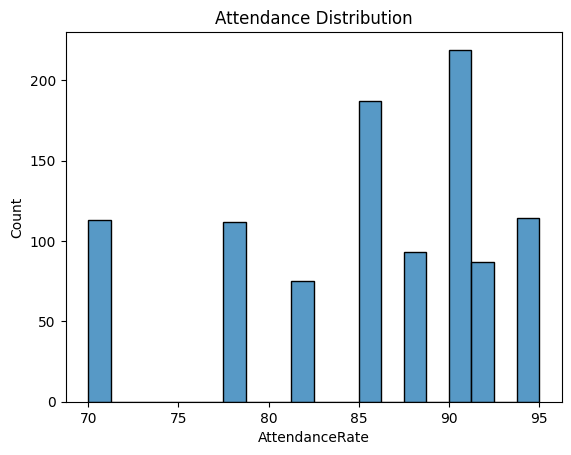

In [ ]:
sns.histplot(df["AttendanceRate"], bins=20)
plt.title("Attendance Distribution")
plt.show()

This histogram shows how student attendance is distributed across the dataset.

**Study Hours vs Final Grade**

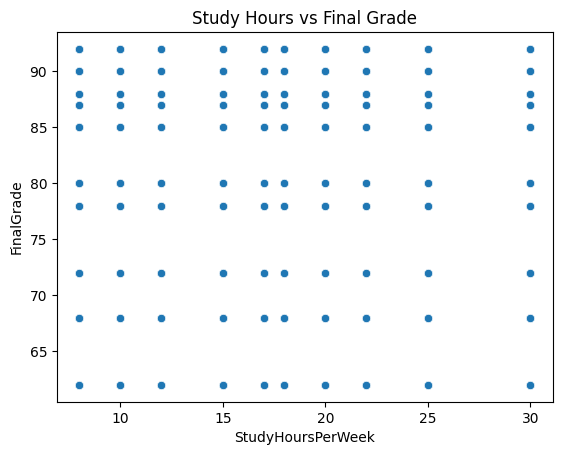

In [ ]:
sns.scatterplot(x=df["StudyHoursPerWeek"], y=df["FinalGrade"])
plt.title("Study Hours vs Final Grade")
plt.show()

This scatter plot shows the relationship between study hours and final grades.

# **A: MULTINOMIAL CLASSIFICATION**

Classification is a supervised machine learning technique used to predict categorical outcomes. In classification problems, the target variable belongs to predefined categories.

In this project, the goal is to classify students into three **performance levels**:


*  **Low** Performance

*   **Medium** Performance
*  **High** Performance



In [ ]:
def performance_category(score):

    if score < 50:
        return "Low"

    elif score < 75:
        return "Medium"

    else:
        return "High"

df["Performance"] = df["FinalGrade"].apply(performance_category)

**Encode Categorical Variables**


*   Machine learning algorithms cannot process text values.
*   Therefore, categorical variables must be converted into numerical values using Label Encoding.



In [ ]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["ExtracurricularActivities"] = le.fit_transform(df["ExtracurricularActivities"])
df["ParentalSupport"] = le.fit_transform(df["ParentalSupport"])
df["Online Classes Taken"] = le.fit_transform(df["Online Classes Taken"])

df["Performance"] = le.fit_transform(df["Performance"])

**Select Features and Target**

Machine learning models require:

*  Features (X) → Input variables used for prediction
*   Target (y) → Output variable we want to predict



In [ ]:
X = df[[
    "Gender",
    "AttendanceRate",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "ExtracurricularActivities",
    "ParentalSupport",
    "Online Classes Taken"
]]

y = df["Performance"]

**Split Dataset into Training and Testing Data**

To evaluate model performance, the dataset is divided into:


1.  **Training Data**-->Used to train the model
2.   **Testing Data**-->Used to evaluate the model

Common split ratio:

* 80% Training

* 20% Testing



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Apply Multinomial Logistic Regression**

* Logistic Regression is used for classification problems.

* Since there are three performance categories, we use Multinomial Logistic Regression.

* This model predicts the probability of each category.

In [ ]:
model = LogisticRegression(multi_class='multinomial', max_iter=200)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial')

**Make Predictions**

After training the model, we use it to predict performance categories for the test data.

In [ ]:
y_pred = model.predict(X_test)

**Model Evaluation**

Accuracy measures the percentage of correct predictions made by the model.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.665


**Confusion Matrix**

* A Confusion Matrix shows how many predictions were correct or incorrect for each category.
* It helps evaluate classification performance.

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[133   0]
 [ 67   0]]


* **133 values** in the first cell indicate that 133 samples belonging to Class 0 were correctly predicted as Class 0.

* **0 values** in the second cell indicate that no samples from Class 0 were incorrectly predicted as Class 1.

* **67 values** in the third cell indicate that 67 samples belonging to Class 1 were incorrectly predicted as Class 0.

* **0 values** in the last cell indicate that the model did not correctly predict any samples belonging to Class 1.

From the confusion matrix, it can be observed that the model predicts most of the samples as Class 0 and fails to correctly identify Class 1. This indicates that the model is biased toward one class and may not be performing well in distinguishing between different performance categories.

# **B: REGRESSION**
Regression is a machine learning technique used to predict continuous numerical values.

* In Regression we use linear regression model

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

**Predict the Final Scores**

After training the model, we use it to predict the FinalGrade values for the test dataset.

In [ ]:
y_pred = model.predict(X_test)

**Model Evaluation**

To measure the performance of the regression model, we use the following metrics:

* R² Score

* Mean Absolute Error (MAE)

* Mean Squared Error (MSE)

**R² Score**

The R² score measures how well the regression model explains the variation in the target variable.

Range of R²:

* 1 -->	Perfect prediction

* 0 -->	Model does not explain data

* <0 -->	Very poor model

Higher R² means better model performance.

In [ ]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: -0.024944721743796583


**Mean Absolute Error (MAE)**

MAE calculates the average absolute difference between predicted and actual values.

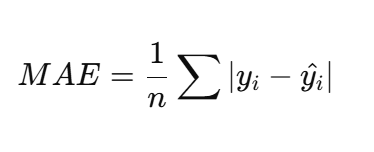

 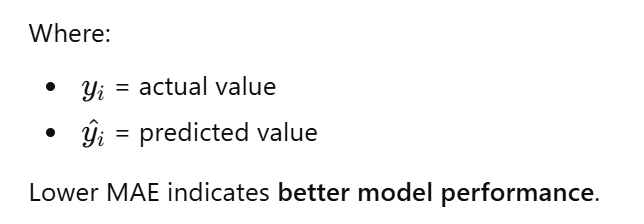

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.43420245391241297


**Mean Squared Error (MSE)**

MSE calculates the average squared difference between predicted and actual values.

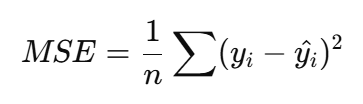

* Lower MSE indicates better accuracy.

In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.22833206038647433


The **R² score** **is negative**, which indicates that the **Linear Regression model does not effectively explain the relationship between the input features and the final score**. A negative R² value means the model performs **worse** than simply predicting the average value of the target variable. and **MAE** and **MSE** values are relatively small, indicating that the prediction errors are not very large.